# Лекци 6. Pandas и обработка данных на Python

Датасет взят из соревнования **Kaggle «Bike Sharing Demand»**. Это реальные данные о прокате велосипедов в Вашингтоне (США) за 2011–2012 годы. Каждая строка — это **один час** наблюдений.

## Столбцы датасета

| Столбец      | Тип                 | Описание                                                                                   |
| ------------ | ------------------- | ------------------------------------------------------------------------------------------ |
| `datetime`   | object (дата+время) | Дата и час наблюдения, формат `YYYY-MM-DD HH:MM:SS`                                        |
| `season`     | int                 | Сезон: 1=Зима, 2=Весна, 3=Лето, 4=Осень                                                    |
| `holiday`    | int                 | Праздничный ли день: 0=нет, 1=да                                                           |
| `workingday` | int                 | Рабочий ли день: 0=нет, 1=да (не выходной и не праздник)                                   |
| `weather`    | int                 | Погода: 1=ясно/малооблачно, 2=туман/облачно, 3=небольшой снег/дождь, 4=сильный дождь/шторм |
| `temp`       | float               | Температура воздуха в °C                                                                   |
| `atemp`      | float               | Ощущаемая температура в °C                                                                 |
| `humidity`   | int                 | Относительная влажность (%)                                                                |
| `windspeed`  | float               | Скорость ветра (условные единицы, нормализованы)                                           |
| `casual`     | int                 | Число поездок случайных (незарегистрированных) пользователей                               |
| `registered` | int                 | Число поездок зарегистрированных пользователей                                             |
| `count`      | int                 | **Итоговое число поездок** = casual + registered (**целевая переменная**)                  |

**Объём:** ~10 886 строк, 12 столбцов, период 2011-01-01 — 2012-12-19, шаг — 1 час.

## Jupyter Notebook, NumPy, Pandas

## 1.1 Среда разработки: Jupyter Notebook

Jupyter Notebook — это интерактивная среда для написания и выполнения Python-кода прямо в браузере. Документ состоит из **ячеек** трёх типов:

- **Code** — Python-код, который выполняется ядром
- **Markdown** — текст с форматированием (заголовки, списки, таблицы)
- **Raw** — «сырой» текст без обработки (используется редко)

### Горячие клавиши (команды ячеек — нажать `Esc` для выхода из редактора)


| Клавиша       | Действие                             |
| ------------- | ------------------------------------ |
| `b`           | Создать ячейку **ниже** (below)      |
| `a`           | Создать ячейку **выше** (above)      |
| `m`           | Сделать ячейку **Markdown**          |
| `y`           | Сделать ячейку **Code**              |
| `dd`          | **Удалить** ячейку                   |
| `Ctrl+Enter`  | **Выполнить** текущую ячейку         |
| `Shift+Enter` | Выполнить и перейти **на следующую** |

## 1.2 Магические команды Jupyter

Магические команды — специальные инструкции, начинающиеся с `%` (строчные) или `%%` (ячеечные).

In [1]:
# Строчная магия: измерить время одной строки
%timeit sum(range(1000000))

27.8 ms ± 1.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [2]:
%%time
# Ячеечная магия: измерить время выполнения всей ячейки
total = 0
for i in range(1000000):
    total += i
print(total)

499999500000
CPU times: total: 266 ms
Wall time: 284 ms


In [3]:
# Показать все доступные магические команды
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javascript

In [4]:
# Встроенная отрисовка графиков (без отдельного окна)
%matplotlib inline

`!pip install openpyxl` — установить библиотеку прямо из ноутбука

## 1.3 Ядро (Kernel) Jupyter

**Ядро** — процесс Python, который хранит все ваши переменные и выполняет код.

Важно знать:
- `In [*]` рядом с ячейкой — ядро занято, ждёт выполнения
- Если ядро «зависло» — нажмите **■ (Stop)** на панели инструментов
- **Restart Kernel** сбрасывает все переменные — все расчёты потеряются!
- Ядро «живёт» пока открыт ноутбук, переменные накапливаются

In [5]:
# Проверим, что ядро работает
print("Ядро запущено! Python готов к работе.")
print(2 + 2)

Ядро запущено! Python готов к работе.
4


## 1.4 Библиотека NumPy

**NumPy** (Numeric Python) — основа для научных вычислений в Python. Написан на C++ «под капотом», поэтому работает **в десятки раз быстрее** обычных списков Python.

Именно NumPy обеспечивает скорость работы pandas, scikit-learn и других ML-библиотек.

In [6]:
import numpy as np

# Создаём матрицу (двумерный массив)
a = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]])

print("Матрица a:")
print(a)
print("Размер матрицы (строки × столбцы):", a.shape)

Матрица a:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
Размер матрицы (строки × столбцы): (4, 3)


In [7]:
# Транспонирование матрицы (поворот на 90°)
print("Транспонированная матрица a.T:")
print(a.T)

Транспонированная матрица a.T:
[[ 1  4  7 10]
 [ 2  5  8 11]
 [ 3  6  9 12]]


In [8]:
# Поэлементные операции (в отличие от math — работает сразу со всем массивом!)
b = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1],
              [1, 1, 1]])

# Скалярные операции применяются ко ВСЕМ элементам сразу
print("a * 2:")
print(a * 2)

print("a + 100:")
print(a + 100)

a * 2:
[[ 2  4  6]
 [ 8 10 12]
 [14 16 18]
 [20 22 24]]
a + 100:
[[101 102 103]
 [104 105 106]
 [107 108 109]
 [110 111 112]]


In [9]:
# Скалярное произведение (dot product)
v = np.array([1, 2, 3])
print("Скалярное произведение a · v:", np.dot(a, v))

Скалярное произведение a · v: [14 32 50 68]


In [10]:
# Полезные функции NumPy
arr = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])

print("Минимум:", arr.min())
print("Максимум:", arr.max())
print("Среднее:", arr.mean())
print("Сумма:", arr.sum())
print("Стандартное отклонение:", arr.std().round(2))

Минимум: 1
Максимум: 9
Среднее: 3.9
Сумма: 39
Стандартное отклонение: 2.34


**Главное про NumPy:** операции применяются сразу ко всему массиву, не нужен цикл `for`. Это называется **векторизация**.

## 1.5 Библиотека pandas

**pandas** — главная библиотека для работы с табличными данными в Python.

Два основных объекта:
- **Series** — один столбец данных (одномерный)
- **DataFrame** — таблица из столбцов Series (двумерная)

In [11]:
import pandas as pd  # принято импортировать как pd

# Создадим простой DataFrame вручную
df_example = pd.DataFrame(
    [("Миша", 28, "Москва"),
     ("Саша", 22, "Казань"),
     ("Илья", 35, "Мурманск")],
    columns=["Имя", "Возраст", "Город"]
)

df_example

,Имя,Возраст,Город
0,Миша,28,Москва
1,Саша,22,Казань
2,Илья,35,Мурманск


In [12]:
# Обращение к одному столбцу — получаем Series
print(type(df_example["Имя"]))  # <class 'pandas.core.series.Series'>
df_example["Возраст"]

<class 'pandas.Series'>


0    28
1    22
2    35
Name: Возраст, dtype: int64

In [13]:
# Базовая информация о таблице
print("Размер таблицы:", df_example.shape)       # (строки, столбцы)
print("Столбцы:", list(df_example.columns))       # список имён
print("Типы данных:\n", df_example.dtypes)        # типы каждого столбца

Размер таблицы: (3, 3)
Столбцы: ['Имя', 'Возраст', 'Город']
Типы данных:
 Имя          str
Возраст    int64
Город        str
dtype: object


## 1.6 Чтение данных из CSV

**CSV** (Comma-Separated Values) — самый распространённый формат для хранения таблиц. Каждая строка — одна запись, столбцы разделены запятой (или другим символом).

In [14]:
import pandas as pd

# Читаем наш датасет — один вызов, и вся таблица загружена!
df = pd.read_csv("5 train.csv")

print("Таблица загружена!")
print("Размер:", df.shape)

Таблица загружена!
Размер: (10886, 12)


In [15]:
# .head() — посмотреть первые N строк (по умолчанию 5)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [16]:
# .tail() — последние N строк
df.tail(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [17]:
# .info() — краткая сводка: типы данных, количество непустых значений
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [18]:
# .describe() — основная статистика по числовым столбцам
# count, mean, std, min, 25%, 50% (медиана), 75%, max
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


| Столбец      | Тип                 | Описание                                                                                   |
| ------------ | ------------------- | ------------------------------------------------------------------------------------------ |
| `datetime`   | object (дата+время) | Дата и час наблюдения, формат `YYYY-MM-DD HH:MM:SS`                                        |
| `season`     | int                 | Сезон: 1=Зима, 2=Весна, 3=Лето, 4=Осень                                                    |
| `holiday`    | int                 | Праздничный ли день: 0=нет, 1=да                                                           |
| `workingday` | int                 | Рабочий ли день: 0=нет, 1=да (не выходной и не праздник)                                   |
| `weather`    | int                 | Погода: 1=ясно/малооблачно, 2=туман/облачно, 3=небольшой снег/дождь, 4=сильный дождь/шторм |
| `temp`       | float               | Температура воздуха в °C                                                                   |
| `atemp`      | float               | Ощущаемая температура в °C                                                                 |
| `humidity`   | int                 | Относительная влажность (%)                                                                |
| `windspeed`  | float               | Скорость ветра (условные единицы, нормализованы)                                           |
| `casual`     | int                 | Число поездок случайных (незарегистрированных) пользователей                               |
| `registered` | int                 | Число поездок зарегистрированных пользователей                                             |
| `count`      | int                 | **Итоговое число поездок** = casual + registered (**целевая переменная**)                  |

In [19]:
# .columns — список имён столбцов
print("Столбцы таблицы:")
for col in df.columns:
    print(f"  - {col}")

Столбцы таблицы:
  - datetime
  - season
  - holiday
  - workingday
  - weather
  - temp
  - atemp
  - humidity
  - windspeed
  - casual
  - registered
  - count


In [20]:
# .dtypes — типы данных каждого столбца
print("Типы данных:")
print(df.dtypes)

Типы данных:
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


**Важно:** pandas использует собственные типы данных. Строки хранятся как `object`, целые числа — `int64`, вещественные — `float64`. Столбец `datetime` здесь тоже `object` — это строка, а не дата. Это мы исправим в Лекции 2.

## 1.7 Проверка на пропущенные значения

Перед анализом всегда нужно проверить: нет ли в данных дыр (пропущенных значений `NaN`).

In [21]:
# .isna() возвращает True там, где данные пропущены
df.isna().head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
# Подсчитаем пропуски по каждому столбцу
print("Количество пропусков по столбцам:")
print(df.isna().sum())

Количество пропусков по столбцам:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [23]:
# Есть ли пропуски хоть где-нибудь?
if df.isna().any().any():
    print("⚠️ В таблице есть пропущенные значения!")
else:
    print("✅ Пропущенных значений нет.")

✅ Пропущенных значений нет.


## 1.8 Matplotlib: основы визуализации

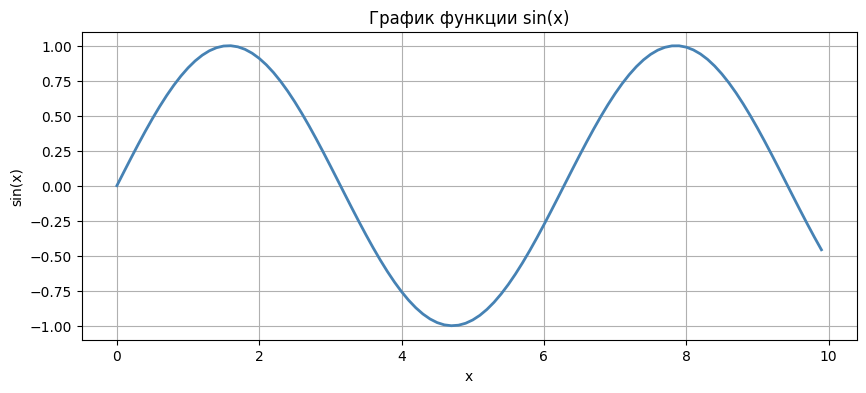

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Простой линейный график
x = np.arange(0, 10, 0.1)       # массив от 0 до 10 с шагом 0.1
y = np.sin(x)                    # синус от каждого элемента

plt.figure(figsize=(10, 4))
plt.plot(x, y, color='steelblue', linewidth=2)
plt.title("График функции sin(x)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

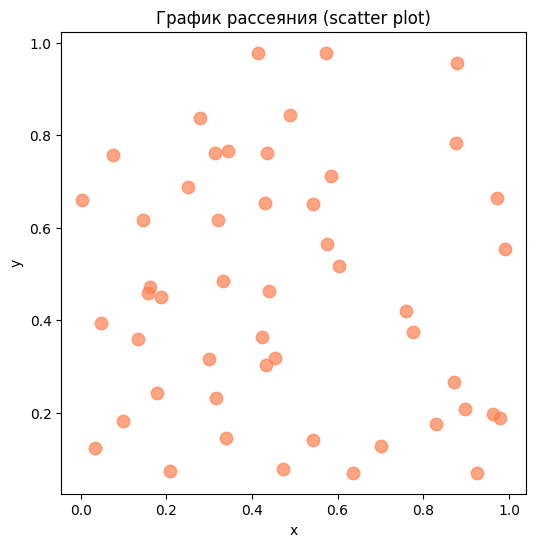

In [25]:
# График точек (scatter plot)
x = np.random.rand(50)
y = np.random.rand(50)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='coral', alpha=0.7, s=80)
plt.title("График рассеяния (scatter plot)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

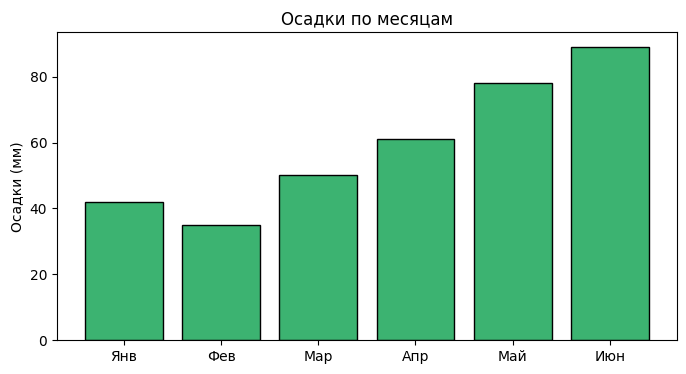

In [26]:
# Столбчатая диаграмма
months = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн"]
rainfall = [42, 35, 50, 61, 78, 89]

plt.figure(figsize=(8, 4))
plt.bar(months, rainfall, color='mediumseagreen', edgecolor='black')
plt.title("Осадки по месяцам")
plt.ylabel("Осадки (мм)")
plt.show()

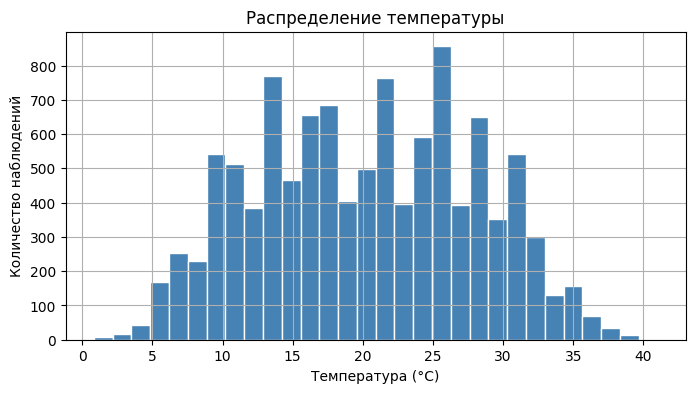

In [27]:
# Простейший график прямо из pandas!
# Построим распределение температуры
df["temp"].hist(bins=30, figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title("Распределение температуры")
plt.xlabel("Температура (°C)")
plt.ylabel("Количество наблюдений")
plt.show()

## Pandas: фильтрация, индексы, группировка, даты и визуализация данных

## 2.1 Повторение: загружаем датасет

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("5 train.csv")
print("Датасет загружен:", df.shape)
df.head()

Датасет загружен: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2.2 Объект Series: под капотом pandas

Когда вы обращаетесь к одному столбцу DataFrame, вы получаете объект **Series**. Это одномерная структура с **индексом** и **значениями**.

In [29]:
# Обращение к столбцу — возвращает Series
s = df["season"]
print(type(s))
print(s.head(10))

<class 'pandas.Series'>
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: season, dtype: int64


In [30]:
# Сравнение столбца с числом возвращает НЕ True/False, а Series из True/False!
mask = df["season"] == 1
print(type(mask))
print(mask.head(10))
print("Тип значений:", mask.dtype)

<class 'pandas.Series'>
0    True
1    True
2    True
3    True
4    True
5    True
6    True
7    True
8    True
9    True
Name: season, dtype: bool
Тип значений: bool


In [31]:
# Создадим Series вручную
s_manual = pd.Series([10, 20, 30, 40, 50], index=["a", "b", "c", "d", "e"])
print(s_manual)
print("Значение по ключу 'c':", s_manual["c"])

a    10
b    20
c    30
d    40
e    50
dtype: int64
Значение по ключу 'c': 30


## 2.3 Фильтрация данных

Фильтрация — один из самых частых операций. Суть: передать в `df[...]` столбец из `True/False`.

In [32]:
# Получить все наблюдения за зиму (season == 1)
winter = df[df["season"] == 1]
print("Зимних наблюдений:", len(winter))
winter.head()

Зимних наблюдений: 2686


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [33]:
# Только рабочие дни
working = df[df["workingday"] == 1]
print("Рабочих дней, наблюдений:", len(working))

Рабочих дней, наблюдений: 7412


### Логическое И (`&`)

Оба условия должны выполняться одновременно. В pandas `and` не работает — только `&`.

In [34]:
# Зима И рабочий день
winter_working = df[
    (df["season"] == 1) & (df["workingday"] == 1)
]
print("Зима + рабочий день:", len(winter_working))
winter_working.head()

Зима + рабочий день: 1828


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
47,2011-01-03 00:00:00,1,0,1,1,9.02,9.850,44,23.9994,0,5,5
48,2011-01-03 01:00:00,1,0,1,1,8.20,8.335,44,27.9993,0,2,2
49,2011-01-03 04:00:00,1,0,1,1,6.56,6.820,47,26.0027,0,1,1
50,2011-01-03 05:00:00,1,0,1,1,6.56,6.820,47,19.0012,0,3,3
51,2011-01-03 06:00:00,1,0,1,1,5.74,5.305,50,26.0027,0,30,30


### Логическое ИЛИ (`|`)

Хотя бы одно из условий выполняется. В pandas `or` не работает — только `|`.

In [35]:
# Влажность < 30% ИЛИ температура > 30°C
extreme = df[
    (df["humidity"] < 30) | (df["temp"] > 30)
]
print("Экстремальных условий:", len(extreme))

Экстремальных условий: 1588


### Логическое НЕ (`~`)

Отрицание условия. В pandas `not` не работает — только `~`.

In [36]:
# НЕ праздничный день
not_holiday = df[
    ~(df["holiday"] == 1)
]
print("Не праздники:", len(not_holiday))
# Эквивалентно: df[df["holiday"] != 1]

Не праздники: 10575


In [37]:
# Комбинируем все три: (не выходной) И (температура между 15 и 25)
comfortable = df[
    (~(df["workingday"] == 0)) & (df["temp"] >= 15) & (df["temp"] <= 25)
]
print("Комфортные рабочие дни:", len(comfortable))
comfortable.head()

Комфортные рабочие дни: 2791


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
420,2011-01-19 13:00:00,1,0,1,1,16.40,20.455,62,19.0012,11,67,78
421,2011-01-19 14:00:00,1,0,1,1,16.40,20.455,58,16.9979,7,68,75
422,2011-01-19 15:00:00,1,0,1,1,16.40,20.455,54,19.0012,4,78,82
423,2011-01-19 16:00:00,1,0,1,1,15.58,19.695,58,26.0027,10,94,104
468,2011-02-02 14:00:00,1,0,1,1,15.58,19.695,82,26.0027,2,61,63


## 2.4 Функции-фильтры

In [38]:
# .isna() — фильтр по пропущенным значениям
# Нельзя: df[df["windspeed"] is None]  ← это не работает!
# Нужно:
missing_wind = df[df["windspeed"].isna()]
print("Строк с пустым windspeed:", len(missing_wind))

Строк с пустым windspeed: 0


In [39]:
# .isin() — значение входит в список допустимых
# Нельзя: df[df["season"] in [2, 3]]  ← не работает!
# Нужно:
warm_seasons = df[df["season"].isin([2, 3])]
print("Весна+Лето:", len(warm_seasons))

Весна+Лето: 5466


In [40]:
# .notna() — противоположность isna()
filled = df[df["windspeed"].notna()]
print("Строк без пропусков в windspeed:", len(filled))

Строк без пропусков в windspeed: 10886


> **Запомнить:** в pandas всегда используются специальные операторы:
> - `is None` → `.isna()`
> - `in [...]` → `.isin([...])`
> - `not` → `~`
> - `and` → `&`
> - `or` → `|`

## 2.5 Индекс и .loc / .iloc

**Индекс** в pandas — это метки строк. По умолчанию — числа 0, 1, 2, ...

In [41]:
# .loc — обращение по МЕТКЕ индекса
print("Строка с индексом 4:")
print(df.loc[4])

Строка с индексом 4:
datetime      2011-01-01 04:00:00
season                          1
holiday                         0
workingday                      0
weather                         1
temp                         9.84
atemp                      14.395
humidity                       75
windspeed                     0.0
casual                          0
registered                      1
count                           1
Name: 4, dtype: object


In [42]:
# Конкретная ячейка: df.loc[строка, столбец]
print("Температура в строке 4:", df.loc[4, "temp"])

Температура в строке 4: 9.84


In [43]:
# .iloc — обращение по ПОРЯДКОВОМУ номеру (как в обычном списке)
print("Первая строка (iloc[0]):")
print(df.iloc[0])

Первая строка (iloc[0]):
datetime      2011-01-01 00:00:00
season                          1
holiday                         0
workingday                      0
weather                         1
temp                         9.84
atemp                      14.395
humidity                       81
windspeed                     0.0
casual                          3
registered                     13
count                          16
Name: 0, dtype: object


In [44]:
# Срезы: iloc работает как list-slicing (правая граница НЕ включается!)
print("Строки 0, 1, 2:")
df.iloc[0:3]

Строки 0, 1, 2:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [45]:
# Установка другого столбца как индекса
df_dt = df.copy().set_index("datetime")
df_dt.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [46]:
# Теперь можем обращаться по дате
df_dt.loc["2011-01-01 12:00:00"]

season         1.0000
holiday        0.0000
workingday     0.0000
weather        1.0000
temp          17.2200
atemp         21.2100
humidity      77.0000
windspeed     19.0012
casual        29.0000
registered    55.0000
count         84.0000
Name: 2011-01-01 12:00:00, dtype: float64

In [47]:
# Диапазон дат через loc (ОБЕ границы включаются!)
df_dt.loc["2011-01-01 10:00:00":"2011-01-01 12:00:00"]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 10:00:00,1,0,0,1,15.58,19.695,76,16.9979,12,24,36
2011-01-01 11:00:00,1,0,0,1,14.76,16.665,81,19.0012,26,30,56
2011-01-01 12:00:00,1,0,0,1,17.22,21.210,77,19.0012,29,55,84


In [48]:
# Сброс индекса обратно
df_dt_reset = df_dt.reset_index()
df_dt_reset.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


## 2.6 Работа с датами: pd.to_datetime

Столбец `datetime` сейчас хранится как строка (`object`). Нужно преобразовать его в настоящий тип даты, чтобы можно было извлекать год, месяц, час и т.д.

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [50]:
# Смотрим тип ДО преобразования
print("Тип ДО:", df["datetime"].dtype)

Тип ДО: str


In [51]:
# Преобразуем в тип datetime
df_1 = df.copy()
df_1["datetime"] = pd.to_datetime(df_1["datetime"])

In [52]:
# Тип ПОСЛЕ
print("Тип ПОСЛЕ:", df_1["datetime"].dtype)
df_1["datetime"].head(3)

Тип ПОСЛЕ: datetime64[us]


0   2011-01-01 00:00:00
1   2011-01-01 01:00:00
2   2011-01-01 02:00:00
Name: datetime, dtype: datetime64[us]

In [53]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [54]:
# Теперь через .dt можно вытащить любую часть даты
print("Месяц:", df_1["datetime"].dt.month.head(5).tolist())
print("Час:", df_1["datetime"].dt.hour.head(5).tolist())
print("День недели (0=пн):", df_1["datetime"].dt.dayofweek.head(5).tolist())

Месяц: [1, 1, 1, 1, 1]
Час: [0, 1, 2, 3, 4]
День недели (0=пн): [5, 5, 5, 5, 5]


In [55]:
# Фильтрация по части даты: только май
may_data = df_1[df_1["datetime"].dt.month == 5]
print("Наблюдений за май:", len(may_data))
may_data.head()

Наблюдений за май: 912


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
1778,2011-05-01 00:00:00,2,0,0,1,17.22,21.210,67,6.0032,19,77,96
1779,2011-05-01 01:00:00,2,0,0,1,17.22,21.210,69,7.0015,9,50,59
1780,2011-05-01 02:00:00,2,0,0,1,17.22,21.210,77,7.0015,7,43,50
1781,2011-05-01 03:00:00,2,0,0,1,16.40,20.455,82,7.0015,8,15,23
1782,2011-05-01 04:00:00,2,0,0,1,16.40,20.455,76,7.0015,6,11,17


In [56]:
# Фильтрация по часу: час пик утром (8:00)
rush_morning = df_1[df_1["datetime"].dt.hour == 8]
print("Наблюдений в 8:00:", len(rush_morning))
print("Среднее число поездок в 8:00:", rush_morning["count"].mean().round(1))

Наблюдений в 8:00: 455
Среднее число поездок в 8:00: 362.8


## 2.7 Группировка данных: groupby + agg


**Группировка** — разбить данные на подгруппы, применить к каждой функцию, получить одно число.

Пример задачи: «Каков средний спрос по каждому сезону?»

In [57]:
# groupby + agg — самый рекомендуемый способ
result = df.groupby("season").agg({"count": "mean"})
result.columns = ["Среднее кол-во поездок"]
result.index = ["Зима", "Весна", "Лето", "Осень"]
result

,Среднее кол-во поездок
Зима,116.343261
Весна,215.251372
Лето,234.417124
Осень,198.988296


In [58]:
# Несколько агрегирующих функций сразу
df.groupby("season").agg({
    "temp": "mean",      # средняя температура
    "count": ["mean", "max", "sum"]  # среднее, макс, сумма поездок
}).round(1)

temp  count             
        mean   mean  max     sum
season                          
1       12.5  116.3  801  312498
2       22.8  215.3  873  588282
3       28.8  234.4  977  640662
4       16.6  199.0  948  544034

In [59]:
# Группировка по двум столбцам
df.groupby(["season", "workingday"]).agg({"count": "mean"}).round(1)

count
season workingday       
1      0           105.7
       1           121.3
2      0           222.7
       1           211.9
3      0           232.5
       1           235.3
4      0           192.1
       1           202.3

In [60]:
# Группировка по часам суток — ищем пиковые часы
hourly = df_1.groupby(df_1["datetime"].dt.hour).agg({"count": "mean"})
hourly.columns = ["Среднее число поездок"]
print("Топ-5 часов по количеству поездок:")
print(hourly.sort_values("Среднее число поездок", ascending=False).head())

Топ-5 часов по количеству поездок:
          Среднее число поездок
datetime                       
17                   468.765351
18                   430.859649
8                    362.769231
16                   316.372807
19                   315.278509


In [61]:
# Группировка по месяцам
monthly = df_1.groupby(df_1["datetime"].dt.month).agg({
    "count": "sum",
    "temp": "mean"
})
monthly.columns = ["Всего поездок", "Средняя температура"]
monthly.index.name = "Месяц"
monthly

,Всего поездок,Средняя температура
Месяц,,
1,79884,9.840000
2,99113,11.798535
3,133501,15.902175
4,167402,18.718372
5,200147,22.674079
6,220733,27.064496
7,214617,30.841711
8,213516,29.736689
9,212529,25.779032


## 2.8 Визуализация: pandas + matplotlib

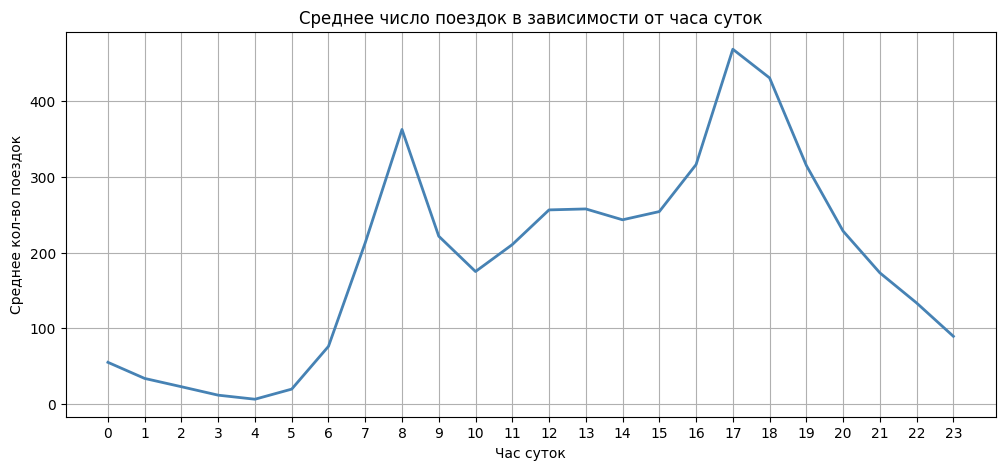

In [62]:
# Среднее число поездок по часам суток
hourly_avg = df_1.groupby(df_1["datetime"].dt.hour).agg({"count": "mean"})

hourly_avg.plot(
    figsize=(12, 5),
    title="Среднее число поездок в зависимости от часа суток",
    xlabel="Час суток",
    ylabel="Среднее кол-во поездок",
    grid=True,
    legend=False,
    color="steelblue",
    linewidth=2
)
plt.xticks(range(0, 24))
plt.show()

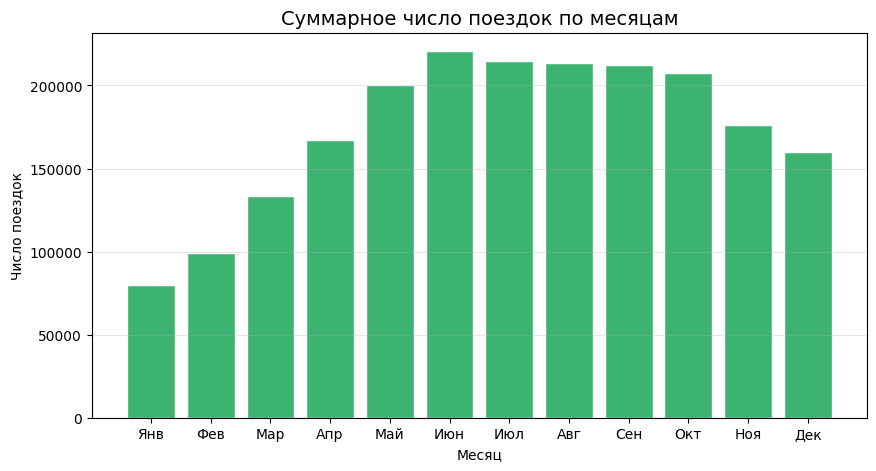

In [63]:
# Сезонная динамика: суммарные поездки по месяцам
monthly_count = df_1.groupby(df_1["datetime"].dt.month).agg({"count": "sum"})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 13), monthly_count["count"], color="mediumseagreen", edgecolor="white")
ax.set_title("Суммарное число поездок по месяцам", fontsize=14)
ax.set_xlabel("Месяц")
ax.set_ylabel("Число поездок")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
                     "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"])
ax.grid(axis="y", alpha=0.3)
plt.show()

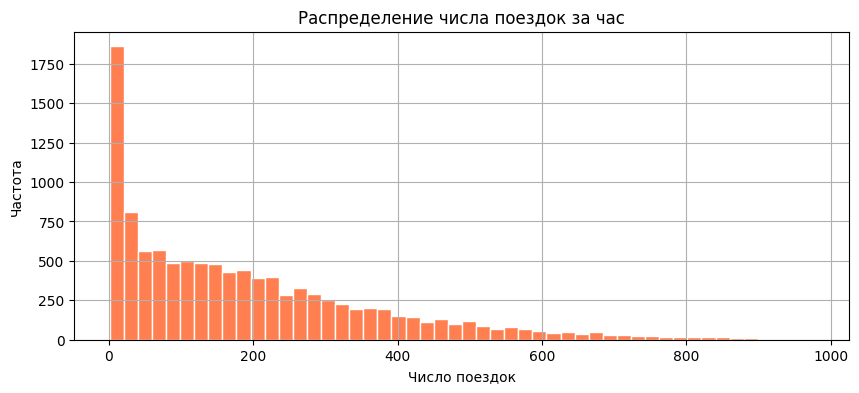

In [64]:
# Гистограмма числа поездок
df["count"].hist(bins=50, figsize=(10, 4), color="coral", edgecolor="white")
plt.title("Распределение числа поездок за час")
plt.xlabel("Число поездок")
plt.ylabel("Частота")
plt.show()

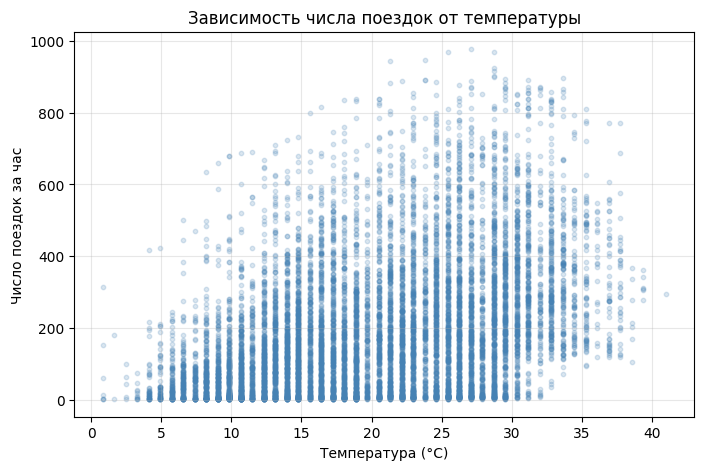

In [65]:
# Scatter plot: температура vs количество поездок
plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["count"], alpha=0.2, color="steelblue", s=10)
plt.title("Зависимость числа поездок от температуры")
plt.xlabel("Температура (°C)")
plt.ylabel("Число поездок за час")
plt.grid(True, alpha=0.3)
plt.show()

## 2.9 Сохранение данных

In [69]:
# Сохраняем обработанный датасет в CSV
# sep=";" — лучше читается в Excel на русском
monthly_count.to_csv("monthly_rides.csv", sep=";")
print("Файл сохранён: monthly_rides.csv")

Файл сохранён: monthly_rides.csv


In [72]:
df.head(100).to_excel("train_sample.xlsx", index=False, engine="openpyxl")
print("Excel файл сохранён: train_sample.xlsx")

Excel файл сохранён: train_sample.xlsx


In [73]:
# Прочитать сохранённый Excel обратно
df_excel = pd.read_excel("train_sample.xlsx", engine="openpyxl")
print("Загружено строк:", len(df_excel))
df_excel.head()

Загружено строк: 100


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Загружаем данные
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# 2. Базовый осмотр
print("=== ОБЗОР ДАТАСЕТА ===")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
print(f"Период: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Пропуски: {df.isna().sum().sum()}")

# 3. Топ-3 самых загруженных часа
print("\n=== ТОП-3 ЧАСА ПО ПОЕЗДКАМ ===")
top_hours = (df.groupby(df["datetime"].dt.hour)["count"]
               .mean()
               .sort_values(ascending=False)
               .head(3))
for hour, avg in top_hours.items():
    print(f"  {hour:02d}:00 — {avg:.0f} поездок в среднем")

# 4. Влияние погоды
print("\n=== СРЕДНЕЕ ПОЕЗДОК ПО ТИПУ ПОГОДЫ ===")
weather_labels = {1: "Ясно", 2: "Облачно/туман", 3: "Дождь/снег", 4: "Шторм"}
weather_stats = df.groupby("weather")["count"].mean()
for w, avg in weather_stats.items():
    label = weather_labels.get(w, str(w))
    print(f"  {label}: {avg:.0f} поездок")

=== ОБЗОР ДАТАСЕТА ===
Строк: 10886, Столбцов: 12
Период: 2011-01-01 00:00:00 → 2012-12-19 23:00:00
Пропуски: 0

=== ТОП-3 ЧАСА ПО ПОЕЗДКАМ ===
  17:00 — 469 поездок в среднем
  18:00 — 431 поездок в среднем
  08:00 — 363 поездок в среднем

=== СРЕДНЕЕ ПОЕЗДОК ПО ТИПУ ПОГОДЫ ===
  Ясно: 205 поездок
  Облачно/туман: 179 поездок
  Дождь/снег: 119 поездок
  Шторм: 164 поездок


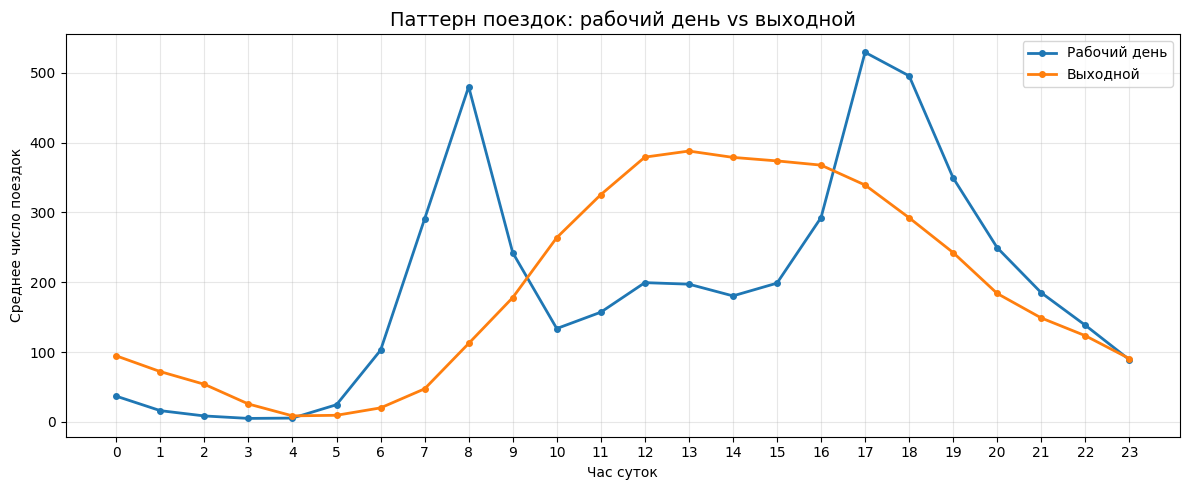

In [75]:
# 5. Визуализация: рабочие vs выходные по часам
fig, ax = plt.subplots(figsize=(12, 5))

for label, val in [("Рабочий день", 1), ("Выходной", 0)]:
    subset = df[df["workingday"] == val]
    hourly = subset.groupby(subset["datetime"].dt.hour)["count"].mean()
    ax.plot(hourly.index, hourly.values, linewidth=2, label=label, marker="o", markersize=4)

ax.set_title("Паттерн поездок: рабочий день vs выходной", fontsize=14)
ax.set_xlabel("Час суток")
ax.set_ylabel("Среднее число поездок")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 1


In [76]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Загружаем данные
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

# ============================================
# Задание 1: найти час суток с максимальным числом поездок в выходные дни
# ============================================

# Фильтруем выходные дни (workingday == 0)
weekend = df[df["workingday"] == 0]

# Группируем по часу и считаем среднее число поездок
hourly_weekend = weekend.groupby(weekend["datetime"].dt.hour)["count"].mean()

# Находим час с максимальным средним числом поездок
max_hour = hourly_weekend.idxmax()
max_value = hourly_weekend.max()

print("=== ЗАДАНИЕ 1 ===")
print(f"Час суток с максимальным числом поездок в выходные дни: {max_hour}:00")
print(f"Среднее число поездок в этот час: {max_value:.1f}")
print()

=== ЗАДАНИЕ 1 ===
Час суток с максимальным числом поездок в выходные дни: 13:00
Среднее число поездок в этот час: 387.8



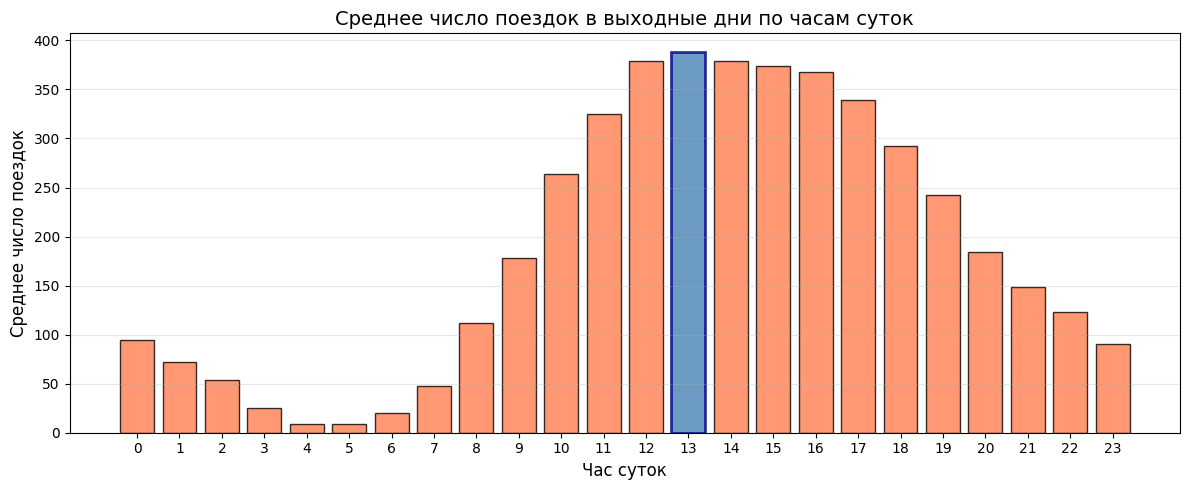

=== ЗАДАНИЕ 2 ===
Столбчатая диаграмма построена выше.
Максимальное значение выделено синим цветом (час 13:00)



In [77]:
# Задание 2: построить столбчатую диаграмму
# ============================================

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 5))
bars = plt.bar(hourly_weekend.index, hourly_weekend.values, 
               color='coral', edgecolor='black', alpha=0.8)

# Подсвечиваем час с максимальным значением
bars[max_hour].set_color('steelblue')
bars[max_hour].set_edgecolor('darkblue')
bars[max_hour].set_linewidth(2)

plt.title("Среднее число поездок в выходные дни по часам суток", fontsize=14)
plt.xlabel("Час суток", fontsize=12)
plt.ylabel("Среднее число поездок", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("=== ЗАДАНИЕ 2 ===")
print("Столбчатая диаграмма построена выше.")
print(f"Максимальное значение выделено синим цветом (час {max_hour}:00)")
print()

=== ЗАДАНИЕ 3 ===
Среднее число поездок по сезонам:
        Случайные (незарегистрированные)  Зарегистрированные
season                                                      
Зима                                15.5               100.9
Весна                               47.4               167.8
Лето                                52.2               182.2
Осень                               28.6               170.4



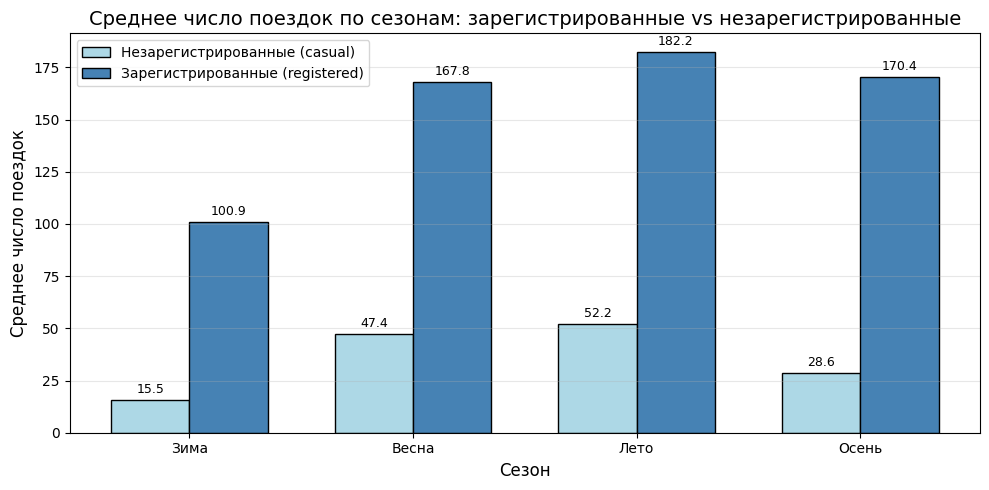

In [78]:
# Задание 3: Среднее число поездок для зарегистрированных и незарегистрированных пользователей по сезонам
# ============================================

# Группируем по сезонам и считаем среднее для casual и registered
season_stats = df.groupby("season").agg({
    "casual": "mean",
    "registered": "mean"
}).round(1)

# Переименовываем индексы для наглядности
season_names = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
season_stats.index = season_stats.index.map(season_names)

# Переименовываем столбцы
season_stats.columns = ["Случайные (незарегистрированные)", "Зарегистрированные"]

print("=== ЗАДАНИЕ 3 ===")
print("Среднее число поездок по сезонам:")
print(season_stats)
print()

# Дополнительно: строим график для наглядности
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(season_stats))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], season_stats["Случайные (незарегистрированные)"], 
               width, label='Незарегистрированные (casual)', color='lightblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], season_stats["Зарегистрированные"], 
               width, label='Зарегистрированные (registered)', color='steelblue', edgecolor='black')

ax.set_xlabel('Сезон', fontsize=12)
ax.set_ylabel('Среднее число поездок', fontsize=12)
ax.set_title('Среднее число поездок по сезонам: зарегистрированные vs незарегистрированные', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(season_stats.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [79]:
# ЗАГРУЗКА ДАННЫХ 
df = pd.read_csv("5 train.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print("Данные загружены!")
print(f"Размер таблицы: {df.shape}")
print(f"Столбцы: {list(df.columns)}")
print("-" * 50)

# ЗАДАЧА 3: наблюдения с count > 500
high_rides = df[df["count"] > 500]

print("=== ЗАДАЧА 3 ===")
print(f"Количество наблюдений с count > 500: {len(high_rides)}")

# Распределение по сезонам
season_counts = high_rides["season"].value_counts()
season_names = {1: "Зима", 2: "Весна", 3: "Лето", 4: "Осень"}
most_common_season = season_counts.idxmax()

print("\nРаспределение по сезонам:")
for season, count in season_counts.items():
    print(f"  {season_names[season]}: {count} наблюдений")

print(f"\n➡️ Чаще всего count > 500 бывает в: {season_names[most_common_season]}")
print("-" * 50)

Данные загружены!
Размер таблицы: (10886, 12)
Столбцы: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
--------------------------------------------------
=== ЗАДАЧА 3 ===
Количество наблюдений с count > 500: 797

Распределение по сезонам:
  Весна: 281 наблюдений
  Лето: 271 наблюдений
  Осень: 186 наблюдений
  Зима: 59 наблюдений

➡️ Чаще всего count > 500 бывает в: Весна
--------------------------------------------------


In [80]:
monthly_stats = df.groupby(df["datetime"].dt.month).agg(
    avg_temp=("temp", "mean"),
    avg_count=("count", "mean")
).round(1)

# Добавляем названия месяцев
month_names = {
    1: "Янв", 2: "Фев", 3: "Мар", 4: "Апр",
    5: "Май", 6: "Июн", 7: "Июл", 8: "Авг",
    9: "Сен", 10: "Окт", 11: "Ноя", 12: "Дек"
}
monthly_stats["month_name"] = [month_names[m] for m in monthly_stats.index]

# Сохраняем в CSV
monthly_stats.to_csv("monthly_avg_temp_rides.csv", sep=";", encoding="utf-8")

print("=== ЗАДАЧА 4 ===")
print("Таблица сохранена в файл: monthly_avg_temp_rides.csv")
print("\nСодержимое:")
print(monthly_stats[["month_name", "avg_temp", "avg_count"]])

=== ЗАДАЧА 4 ===
Таблица сохранена в файл: monthly_avg_temp_rides.csv

Содержимое:
         month_name  avg_temp  avg_count
datetime                                
1               Янв       9.8       90.4
2               Фев      11.8      110.0
3               Мар      15.9      148.2
4               Апр      18.7      184.2
5               Май      22.7      219.5
6               Июн      27.1      242.0
7               Июл      30.8      235.3
8               Авг      29.7      234.1
9               Сен      25.8      233.8
10              Окт      20.9      227.7
11              Ноя      15.2      193.7
12              Дек      13.8      175.6
